Метрики и извлечение предсказанной маски из Mask2Former

In [1]:
import time
import copy
from contextlib import nullcontext

import torch
import torch.nn.functional as F

def dice_score(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    """
    pred, target: (B,H,W) {0,1} float/bool
    returns mean Dice over batch
    """
    pred = pred.float()
    target = target.float()
    inter = (pred * target).sum(dim=(1,2))
    denom = pred.sum(dim=(1,2)) + target.sum(dim=(1,2))
    return ((2 * inter + eps) / (denom + eps)).mean()


def get_pred_mask_from_output(output, target_hw, target_class: int = 1):
    """
    Для Mask2FormerForUniversalSegmentation:
    output.class_queries_logits: (B, Q, C+1)  (обычно +1 = no-object)
    output.masks_queries_logits: (B, Q, h, w)

    Собираем семантические logits (B, C, h, w) как смесь query-масок с весами class-prob,
    затем апсемплим до target_hw и берём argmax по классам.
    Возвращаем бинарную маску для target_class.
    """
    if (not hasattr(output, "class_queries_logits")) or (not hasattr(output, "masks_queries_logits")):
        raise RuntimeError("Выход модели не содержит class_queries_logits/masks_queries_logits. Проверь, что это Mask2FormerForUniversalSegmentation.")

    class_logits = output.class_queries_logits  # (B,Q,Cq)
    mask_logits  = output.masks_queries_logits  # (B,Q,h,w)


    class_probs = class_logits.softmax(dim=-1)[..., :-1]  # (B,Q,C)


    mask_probs = mask_logits.sigmoid()  # (B,Q,h,w)


    sem = torch.einsum("bqc,bqhw->bchw", class_probs, mask_probs)

    sem = F.interpolate(sem, size=target_hw, mode="bilinear", align_corners=False)

    pred_class = sem.argmax(dim=1)  # (B,H,W)
    pred_bin = (pred_class == target_class)
    return pred_bin

Подготовка COCO-разметки и датасета под 3 класса (фон / артерия / катетер)

In [2]:
import json
import cv2
import numpy as np

def load_coco_annotations(json_path):
    """
    Загружает данные разметки COCO из JSON-файла.
    """
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return data

def create_mask(image_info, annotations, category_id, height, width):
    """
    Создаёт маску для указанного изображения и категории.
    Для каждой аннотации текущего изображения, если категория совпадает,
    отрисовывается полигон или декодируется RLE.
    """
    mask = np.zeros((height, width), dtype=np.uint8)
    
    for ann in annotations:
        if ann["image_id"] == image_info["id"] and ann["category_id"] == category_id:
            segmentation = ann["segmentation"]
            if isinstance(segmentation, list):
                for seg in segmentation:
                    points = np.array(seg).reshape(-1, 2).astype(np.int32)
                    cv2.fillPoly(mask, [points], color=255)
            else:
                try:
                    from pycocotools import mask as maskUtils
                    segm = data["annotations"][0]["segmentation"]
                    if isinstance(segm["counts"], list):
                        segm = maskUtils.frPyObjects(segm, segm['size'][0], segm['size'][1])

                    decoded_mask = maskUtils.decode(segm)
                    # Объединяем маски, если таких аннотаций несколько
                    mask = np.maximum(mask, decoded_mask)
                except ImportError:
                    print("Ошибка: не установлен пакет pycocotools, необходимый для декодирования RLE!")
    return mask

json_path = "/home/diburakov/Segmentation/RCA_dataset/annotations/instances_Train.json"
data = load_coco_annotations(json_path)

segment_data = {}

for image_info in data['images']:
    segment_data[image_info['id']] = {'image_info' : image_info, 'segments': []}
    for segm in data['annotations']:
        if segm['image_id'] == image_info['id']:
            segment_data[image_info['id']]['segments'].append(segm)
            
rca_images = {}

for key, info in segment_data.items():
    for segments in info['segments']:
        if segments['category_id'] == 3:
            rca_images[key] = info
            break
            
from pycocotools import mask as maskUtils

def create_mask_from_rle(image_info, category_id):
    """
    Создаёт маску для указанного изображения и категории.
    Для каждой аннотации текущего изображения, если категория совпадает,
    отрисовывается полигон или декодируется RLE.
    """
    decoded_mask = np.zeros((image_info['image_info']['height'], image_info['image_info']['width']))
    for ann in image_info['segments']:
        if ann["category_id"] == category_id:
            segm = ann['segmentation']
            if isinstance(segm["counts"], list):
                segm = maskUtils.frPyObjects(segm, segm['size'][0], segm['size'][1])

            decoded_mask = maskUtils.decode(segm)
    return decoded_mask

import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

class MaskFormerRCADataset(Dataset):
    def __init__(self, rca_images, transform=None):
        self.transform = transform
        self.cathegories = [1, 3, 4, 5, 6, 7]
        self.img_paths = []
        self.masks = []

        for img_inf in rca_images.values():
            self.img_paths.append(img_inf['image_info']['file_name'])
            mask = []
            comb_masks = []

            for cat_id in self.cathegories:
                m = create_mask_from_rle(img_inf, cat_id)
                if cat_id == 1:
                    mask.append(m)
                else:
                    comb_masks.append(m)

            # Объединение категорий 3–7
            mask.append(np.any(comb_masks, axis=0).astype(np.uint8))

            # Формируем 1-канальную маску: фон=0, cat1=1, cat3-7=2
            final_mask = np.zeros_like(mask[0], dtype=np.uint8)
            final_mask[mask[0] == 1] = 1
            final_mask[mask[1] == 1] = 2

            self.masks.append(final_mask)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = '/home/diburakov/Segmentation/RCA_dataset/images/Train/' + self.img_paths[idx]
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # (H, W)

        # Преобразуем в RGB (3 одинаковых канала)
        image = np.stack([image] * 3, axis=-1)  # (H, W, 3)

        mask = self.masks[idx]  # (H, W)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask

In [3]:
def to_bchw_float_rgb(x: torch.Tensor) -> torch.Tensor:
    """
    Приводит вход к формату (B,3,H,W) float32.
    Поддерживает:
      - BCHW (B,1/3/4,H,W)
      - BHWC (B,H,W,1/3/4)
      - CHW / HWC (добавит batch)
    """

    if x.ndim == 3:
        if x.shape[-1] in (1, 3, 4):
            x = x.unsqueeze(0)        
        else:
            x = x.unsqueeze(0)         
    elif x.ndim != 4:
        raise ValueError(f"Unexpected image tensor shape: {tuple(x.shape)}")

    if x.shape[-1] in (1, 3, 4) and x.shape[1] not in (1, 3, 4):
        x = x.permute(0, 3, 1, 2).contiguous()  # B,C,H,W

    if x.shape[1] == 1:
        x = x.repeat(1, 3, 1, 1)
    elif x.shape[1] == 4:
        x = x[:, :3, :, :]  # отбросить alpha/лишний канал
    elif x.shape[1] != 3:
        raise ValueError(f"Expected 1/3/4 channels, got {x.shape[1]} with shape {tuple(x.shape)}")

    if x.dtype == torch.uint8:
        x = x.float().div_(255.0)
    else:
        x = x.float()

    return x

Быстрая валидация Dice по val_loader (с опциональным AMP)

In [4]:
@torch.no_grad()
def evaluate_dice(
    model,
    processor,
    val_loader,
    device: str = "cuda",
    use_amp: bool = False,
    amp_dtype: torch.dtype = torch.float16,
    max_batches: int | None = None,
    target_class: int = 1,
):
    model.eval().to(device)

    amp_ctx = torch.autocast("cuda", dtype=amp_dtype) if (use_amp and device == "cuda") else nullcontext()

    dices = []
    t0 = time.perf_counter()

    for bi, batch in enumerate(val_loader):
        if max_batches is not None and bi >= max_batches:
            break

        images, gt = batch


        if isinstance(images, torch.Tensor):
            x = to_bchw_float_rgb(images)
            pixel_values = x.to(device, non_blocking=True)
            target_hw = (gt.shape[-2], gt.shape[-1])
        else:
            # images — список PIL
            inputs = processor(images=list(images), return_tensors="pt")
            pixel_values = inputs["pixel_values"].to(device, non_blocking=True)
            target_hw = (gt.shape[-2], gt.shape[-1])

        # gt может быть long с классами или бинарной маской
        gt = gt.to(device, non_blocking=True)
        if gt.dtype != torch.bool:
            # если gt в классах, делаем бинарку по target_class
            gt_bin = (gt == target_class)
        else:
            gt_bin = gt

        with amp_ctx:
            output = model(pixel_values=pixel_values)
            pred_bin = get_pred_mask_from_output(output, target_hw, target_class=target_class)

        dices.append(dice_score(pred_bin, gt_bin).item())

    t1 = time.perf_counter()
    return {
        "dice_mean": float(sum(dices) / max(1, len(dices))),
        "time_s": float(t1 - t0),
        "batches": int(len(dices)),
    }

Structured pruning Mask2Former: обрезка decoder layers и числа queries

BASE_fp32

Что это: базовая (полная) модель, вычисления в float32.

Плюсы: максимально стабильная и обычно самая “честная” по точности.

Минусы: чаще всего медленнее и потребляет больше VRAM.


AMP

Что это: та же базовая модель, но включён Automatic Mixed Precision через torch.autocast.

Как работает: часть операций делается в float16 или bfloat16 (в зависимости от amp_dtype), а часть остаётся в fp32 там, где это важно.

Зачем: обычно даёт ускорение и снижение расхода памяти на GPU.

Риск: иногда может чуть ухудшить метрику (редко на инференсе, чаще на обучении), или дать нестабильность на некоторых комбинациях GPU/типов данных.



L3

Что это: pruned вариант модели, где оставили только первые 3 слоя decoder’а (keep_decoder_layers=3).

Эффект: меньше вычислений → обычно быстрее и меньше памяти.

Компромисс: может падать качество, потому что декодер “менее глубокий” и хуже уточняет сегментацию.



Q50

Что это: pruned вариант, где уменьшили число queries до 50 (keep_queries=50).

Что такое queries в Mask2Former: это “набор объектов/масок-кандидатов”, которые модель пытается предсказать. Больше queries → больше “слотов” для разных регионов/объектов.

Эффект: меньше queries → быстрее (особенно в декодере), меньше памяти.

Компромисс: если queries слишком мало, модель может не хватать слотов для всех нужных масок/частей, качество может просесть.




L3Q50

Что это: комбинация двух прунингов: 3 decoder layers + 50 queries.

Эффект: обычно самый быстрый из этих pruned-вариантов.

Компромисс: потенциально наибольшая потеря качества, потому что урезано сразу в двух местах.

In [10]:
import copy
import torch

def _get_attr_by_path(obj, path):
    cur = obj
    for p in path:
        cur = getattr(cur, p)
    return cur

def _set_attr_by_path(obj, path, value):
    cur = obj
    for p in path[:-1]:
        cur = getattr(cur, p)
    setattr(cur, path[-1], value)

def structured_prune_mask2former(model, keep_decoder_layers=None, keep_queries=None, verbose=True):
    """
    Рабочий structured pruning для HF Mask2Former:
      - keep_decoder_layers: оставить первые K слоёв decoder
      - keep_queries: оставить первые Q queries (важно: режем И queries_embedder, И queries_features)
    """
    m = copy.deepcopy(model)

    # ---- decoder layers ----
    layers_paths = [
        ["model", "transformer_module", "decoder", "layers"],
        ["model", "model", "transformer_module", "decoder", "layers"],
        ["transformer_module", "decoder", "layers"],
    ]
    layers_path = None
    for p in layers_paths:
        try:
            x = _get_attr_by_path(m, p)
            if isinstance(x, torch.nn.ModuleList):
                layers_path = p
                break
        except Exception:
            pass

    if keep_decoder_layers is not None:
        if layers_path is None:
            raise RuntimeError("Не нашёл decoder.layers в модели.")
        layers = _get_attr_by_path(m, layers_path)
        _set_attr_by_path(m, layers_path, torch.nn.ModuleList(list(layers)[:keep_decoder_layers]))

    # ---- queries (embedder + features) ----
    q_embed_paths = [
        ["model", "transformer_module", "queries_embedder"],
        ["model", "model", "transformer_module", "queries_embedder"],
        ["transformer_module", "queries_embedder"],
    ]
    q_feat_paths = [
        ["model", "transformer_module", "queries_features"],
        ["model", "model", "transformer_module", "queries_features"],
        ["transformer_module", "queries_features"],
    ]

    q_embed_path = None
    for p in q_embed_paths:
        try:
            x = _get_attr_by_path(m, p)
            if isinstance(x, torch.nn.Embedding):
                q_embed_path = p
                break
        except Exception:
            pass

    q_feat_path = None
    for p in q_feat_paths:
        try:
            x = _get_attr_by_path(m, p)
            if isinstance(x, torch.nn.Embedding):
                q_feat_path = p
                break
        except Exception:
            pass

    if keep_queries is not None:
        if q_embed_path is None or q_feat_path is None:
            raise RuntimeError("Не нашёл queries_embedder и/или queries_features в модели.")

        qemb = _get_attr_by_path(m, q_embed_path)
        qfeat = _get_attr_by_path(m, q_feat_path)

        # режем embedder
        new_qemb = torch.nn.Embedding(keep_queries, qemb.embedding_dim)
        with torch.no_grad():
            new_qemb.weight.copy_(qemb.weight[:keep_queries])
        _set_attr_by_path(m, q_embed_path, new_qemb)

        # режем features
        new_qfeat = torch.nn.Embedding(keep_queries, qfeat.embedding_dim)
        with torch.no_grad():
            new_qfeat.weight.copy_(qfeat.weight[:keep_queries])
        _set_attr_by_path(m, q_feat_path, new_qfeat)

        # на всякий: обновим config, если есть
        if hasattr(m, "config") and hasattr(m.config, "num_queries"):
            m.config.num_queries = keep_queries

    if verbose:
        if layers_path is not None:
            print("Decoder layers:", len(_get_attr_by_path(m, layers_path)))
        if keep_queries is not None:
            print("Queries:", _get_attr_by_path(m, q_embed_path).num_embeddings,
                  _get_attr_by_path(m, q_feat_path).num_embeddings)

    return m

In [7]:
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation
from torch.utils.data import DataLoader
import torch
from torch.optim import Adam
from torch.utils.data import Subset
from sklearn.model_selection import KFold
import albumentations as A
from sklearn.model_selection import train_test_split

metrics = []

num_cross_folds = 5

transform_test = A.Compose([
    A.Resize(height=512, width=512),
])

model_ckpt = "facebook/mask2former-swin-small-coco-instance"
processor = AutoImageProcessor.from_pretrained(model_ckpt)

kfold = KFold(n_splits=num_cross_folds, shuffle=True, random_state=42)
full_dataset = MaskFormerRCADataset(rca_images, transform=transform_test)

model = Mask2FormerForUniversalSegmentation.from_pretrained(
                    model_ckpt,
                    num_labels=3,
                    ignore_mismatched_sizes=True
                )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
state_dict = torch.load(f'/home/diburakov/Segmentation/Train_val_test/Folds_weights_Msk2Former/best_model_fold_0.pth', map_location=device)
model.to(device)
model.load_state_dict(state_dict)

val_loader = DataLoader(full_dataset, batch_size=8, shuffle=False)

Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-small-coco-instance and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([81]) in the checkpoint and torch.Size([4]) in the model instantiated
- class_predictor.weight: found shape torch.Size([81, 256]) in the checkpoint and torch.Size([4, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([81]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/job-3677216/ipykernel_32816/473176785.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://githu

In [8]:
base_layers_path, base_q_path = find_mask2former_decoder_and_queries(model)
print("Base paths:", base_layers_path, base_q_path)

mL3  = structured_prune_mask2former(model, keep_decoder_layers=3, keep_queries=None, verbose=True)
mQ50 = structured_prune_mask2former(model, keep_decoder_layers=None, keep_queries=50, verbose=True)
mB   = structured_prune_mask2former(model, keep_decoder_layers=3, keep_queries=50, verbose=True)

Base paths: ['model', 'transformer_module', 'decoder', 'layers'] ['model', 'transformer_module', 'queries_embedder']
Found layers_path: ['model', 'transformer_module', 'decoder', 'layers']
Found queries_path: ['model', 'transformer_module', 'queries_embedder']
Decoder layers now: 3
Queries now: 100
Found layers_path: ['model', 'transformer_module', 'decoder', 'layers']
Found queries_path: ['model', 'transformer_module', 'queries_embedder']
Decoder layers now: 9
Queries now: 50
Found layers_path: ['model', 'transformer_module', 'decoder', 'layers']
Found queries_path: ['model', 'transformer_module', 'queries_embedder']
Decoder layers now: 3
Queries now: 50


Проверка производительности для максимального количества батчей в датасете

In [11]:
def compare_dice_methods(model, processor, val_loader, device="cuda", amp_dtype=torch.float16, target_class=2, max_batches=50):
    methods = [
        ("BASE_fp32", model, dict(use_amp=False)),
        ("AMP", model, dict(use_amp=True)),
        ("L3", structured_prune_mask2former(model, keep_decoder_layers=3, keep_queries=None, verbose=False), dict(use_amp=True)),
        ("Q50", structured_prune_mask2former(model, keep_decoder_layers=None, keep_queries=50, verbose=False), dict(use_amp=True)),
        ("L3Q50", structured_prune_mask2former(model, keep_decoder_layers=3, keep_queries=50, verbose=False), dict(use_amp=True)),
    ]

    rows = []
    for name, m, opts in methods:
        m = m.to(device).eval()
        res = evaluate_dice(
            m, processor, val_loader,
            device=device,
            use_amp=opts["use_amp"],
            amp_dtype=amp_dtype,
            max_batches=max_batches,
            target_class=target_class,
        )
        rows.append((name, res["dice_mean"], res["time_s"], res["batches"]))
        print(f"{name:8s}  Dice={res['dice_mean']:.4f}  time={res['time_s']:.2f}s  batches={res['batches']}")
    return rows

dice_rows = compare_dice_methods(model, processor, val_loader, device="cuda", amp_dtype=torch.float16, target_class=2, max_batches=50)
dice_rows

BASE_fp32  Dice=0.8517  time=17.53s  batches=49
AMP       Dice=0.8515  time=13.13s  batches=49
L3        Dice=0.8517  time=12.48s  batches=49
Q50       Dice=0.8399  time=12.63s  batches=49
L3Q50     Dice=0.7745  time=11.90s  batches=49


[('BASE_fp32', 0.8516957115153877, 17.52947684004903, 49),
 ('AMP', 0.8515423670107004, 13.126922119408846, 49),
 ('L3', 0.8516703734592516, 12.483969029039145, 49),
 ('Q50', 0.8398893293069334, 12.625915108248591, 49),
 ('L3Q50', 0.7744781533066107, 11.904590366408229, 49)]

Проведение экспериментов с различным количеством батчей


=== max_batches=10 ===
BASE_fp32 Dice=0.8405  time=3.57s  batches=10
AMP      Dice=0.8404  time=2.70s  batches=10
L3       Dice=0.8405  time=2.50s  batches=10
Q50      Dice=0.8377  time=2.65s  batches=10
L3Q50    Dice=0.7439  time=2.48s  batches=10

=== max_batches=20 ===
BASE_fp32 Dice=0.8525  time=7.04s  batches=20
AMP      Dice=0.8521  time=5.33s  batches=20
L3       Dice=0.8524  time=4.95s  batches=20
Q50      Dice=0.8440  time=5.19s  batches=20
L3Q50    Dice=0.7715  time=4.85s  batches=20

=== max_batches=30 ===
BASE_fp32 Dice=0.8541  time=10.58s  batches=30
AMP      Dice=0.8539  time=8.35s  batches=30
L3       Dice=0.8540  time=7.40s  batches=30
Q50      Dice=0.8447  time=7.72s  batches=30
L3Q50    Dice=0.7708  time=7.30s  batches=30

=== max_batches=40 ===
BASE_fp32 Dice=0.8547  time=14.07s  batches=40
AMP      Dice=0.8546  time=10.66s  batches=40
L3       Dice=0.8547  time=9.86s  batches=40
Q50      Dice=0.8425  time=10.61s  batches=40
L3Q50    Dice=0.7764  time=9.67s  batches

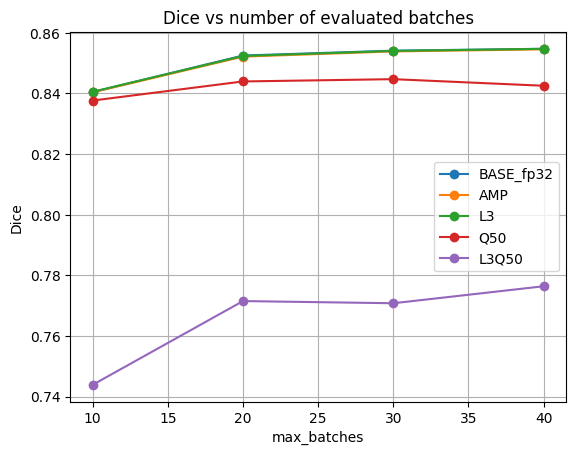

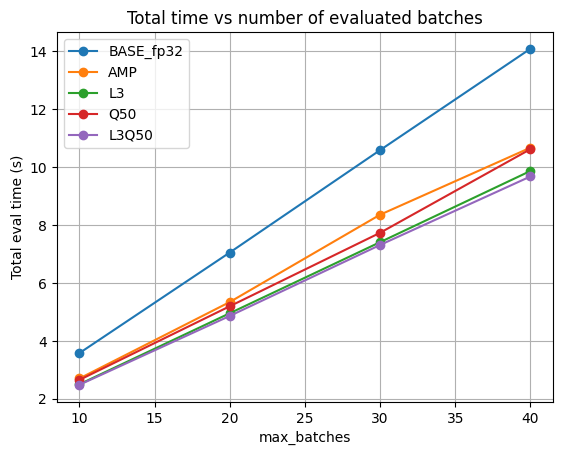

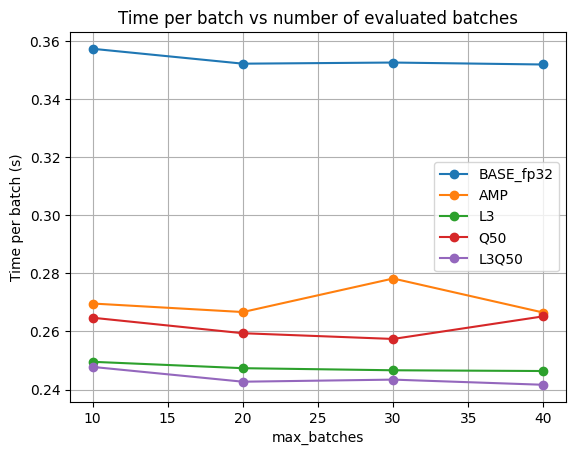

In [15]:
import matplotlib.pyplot as plt
from collections import defaultdict

def run_curves_for_batch_counts_no_pandas(
    model,
    processor,
    val_loader,
    device="cuda",
    amp_dtype=torch.float16,
    target_class=2,
    batch_counts=(5, 10, 20, 30, 40, 49),
):
    m_base = model
    m_amp = model
    m_L3 = structured_prune_mask2former(model, keep_decoder_layers=3, keep_queries=None, verbose=False)
    m_Q50 = structured_prune_mask2former(model, keep_decoder_layers=None, keep_queries=50, verbose=False)
    m_L3Q50 = structured_prune_mask2former(model, keep_decoder_layers=3, keep_queries=50, verbose=False)

    methods = [
        ("BASE_fp32", m_base, dict(use_amp=False)),
        ("AMP",       m_amp,  dict(use_amp=True)),
        ("L3",        m_L3,   dict(use_amp=True)),
        ("Q50",       m_Q50,  dict(use_amp=True)),
        ("L3Q50",     m_L3Q50,dict(use_amp=True)),
    ]

    results = {
        name: {"max_batches": [], "dice": [], "time_s": [], "time_per_batch_s": [], "batches": []}
        for name, _, _ in methods
    }

    for max_b in batch_counts:
        print(f"\n=== max_batches={max_b} ===")
        for name, m, opts in methods:
            m = m.to(device).eval()
            res = evaluate_dice(
                m, processor, val_loader,
                device=device,
                use_amp=opts["use_amp"],
                amp_dtype=amp_dtype,
                max_batches=max_b,
                target_class=target_class,
            )

            results[name]["max_batches"].append(max_b)
            results[name]["dice"].append(res["dice_mean"])
            results[name]["time_s"].append(res["time_s"])
            results[name]["batches"].append(res["batches"])
            results[name]["time_per_batch_s"].append(res["time_s"] / max(1, res["batches"]))

            print(f"{name:8s} Dice={res['dice_mean']:.4f}  time={res['time_s']:.2f}s  batches={res['batches']}")

    return results


def plot_curves_no_pandas(results):
    # 1) Dice vs batches
    plt.figure()
    for method, d in results.items():
        plt.plot(d["max_batches"], d["dice"], marker="o", label=method)
    plt.xlabel("max_batches")
    plt.ylabel("Dice")
    plt.title("Dice vs number of evaluated batches")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2) Total time vs batches
    plt.figure()
    for method, d in results.items():
        plt.plot(d["max_batches"], d["time_s"], marker="o", label=method)
    plt.xlabel("max_batches")
    plt.ylabel("Total eval time (s)")
    plt.title("Total time vs number of evaluated batches")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3) Time per batch vs batches
    plt.figure()
    for method, d in results.items():
        plt.plot(d["max_batches"], d["time_per_batch_s"], marker="o", label=method)
    plt.xlabel("max_batches")
    plt.ylabel("Time per batch (s)")
    plt.title("Time per batch vs number of evaluated batches")
    plt.legend()
    plt.grid(True)
    plt.show()


# ---- Запуск ----
batch_counts = [10, 20, 30, 40]
results_curves = run_curves_for_batch_counts_no_pandas(
    model=model,
    processor=processor,
    val_loader=val_loader,
    device="cuda",
    amp_dtype=torch.float16,
    target_class=2,
    batch_counts=batch_counts,
)

plot_curves_no_pandas(results_curves)

In [12]:
dice_rows = compare_dice_methods(model, processor, val_loader, device="cuda", amp_dtype=torch.bfloat16, target_class=2, max_batches=50)
dice_rows

BASE_fp32  Dice=0.8517  time=17.52s  batches=49
AMP       Dice=0.8517  time=21.43s  batches=49
L3        Dice=0.8516  time=18.48s  batches=49
Q50       Dice=0.8383  time=20.07s  batches=49
L3Q50     Dice=0.7784  time=18.22s  batches=49


[('BASE_fp32', 0.8516957115153877, 17.51650551892817, 49),
 ('AMP', 0.8516959110084845, 21.430855033919215, 49),
 ('L3', 0.8516453687025576, 18.4827748965472, 49),
 ('Q50', 0.8383347769172824, 20.06767701357603, 49),
 ('L3Q50', 0.7784039755256809, 18.223243003711104, 49)]